/opt/homebrew/Cellar/jupyterlab/4.4.6/libexec/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
15:26:32 - cmdstanpy - INFO - Chain [1] start processing
15:26:32 - cmdstanpy - INFO - Chain [1] done processing


Prophet -> MAE: 72.17, RMSE: 84.65, MAPE: 58.29%
XGBoost (kampanyasız) -> MAE: 69.63, RMSE: 106.61, MAPE: 67.00%


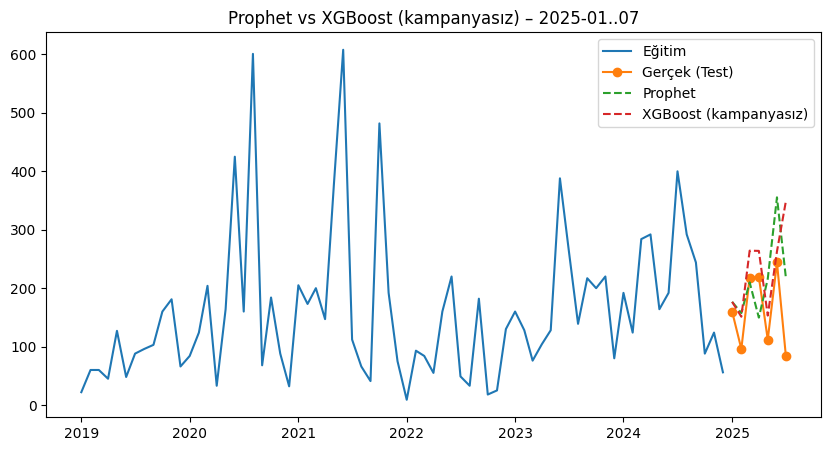

In [1]:
# ======================================
# Prophet vs XGBoost (Kampanyasız Model)
# Train: 2019-01 .. 2024-12
# Test : 2025-01 .. 2025-07
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# ---------- Veri ----------
data = {
"2019-01":22,"2019-02":60,"2019-03":60,"2019-04":45,"2019-05":127,
"2019-06":48,"2019-07":88,"2019-08":96,"2019-09":103,"2019-10":160,
"2019-11":181,"2019-12":66,"2020-01":84,"2020-02":124,"2020-03":204,
"2020-04":33,"2020-05":164,"2020-06":425,"2020-07":160,"2020-08":601,
"2020-09":68,"2020-10":184,"2020-11":88,"2020-12":32,"2021-01":205,
"2021-02":173,"2021-03":200,"2021-04":147,"2021-05":380,"2021-06":608,
"2021-07":112,"2021-08":66,"2021-09":41,"2021-10":482,"2021-11":192,
"2021-12":75,"2022-01":9,"2022-02":93,"2022-03":84,"2022-04":55,
"2022-05":160,"2022-06":220,"2022-07":49,"2022-08":33,"2022-09":182,
"2022-10":18,"2022-11":25,"2022-12":130,"2023-01":160,"2023-02":128,
"2023-03":76,"2023-04":104,"2023-05":128,"2023-06":388,"2023-07":264,
"2023-08":139,"2023-09":217,"2023-10":200,"2023-11":220,"2023-12":80,
"2024-01":192,"2024-02":124,"2024-03":284,"2024-04":292,"2024-05":164,
"2024-06":192,"2024-07":400,"2024-08":292,"2024-09":244,"2024-10":88,
"2024-11":124,"2024-12":56,"2025-01":160,"2025-02":96,"2025-03":218,
"2025-04":219,"2025-05":112,"2025-06":244,"2025-07":84
}

df = pd.DataFrame(list(data.items()), columns=["ds","y"])
df["ds"] = pd.to_datetime(df["ds"])

# Train/Test ayır
train = df[df["ds"] <= "2024-12-01"]
test  = df[(df["ds"] >= "2025-01-01") & (df["ds"] <= "2025-07-01")]

y_true = test["y"].values

# ---------- Prophet ----------
prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False)
prophet.fit(train.rename(columns={"ds":"ds","y":"y"}))
future = prophet.make_future_dataframe(periods=len(test), freq="MS")
fcst = prophet.predict(future)
prophet_pred = fcst[fcst["ds"].isin(test["ds"])]["yhat"].values

# ---------- XGBoost (kampanyasız) ----------
def add_features(df):
    df["month"] = df["ds"].dt.month
    df["year"] = df["ds"].dt.year
    df["is_summer"] = df["ds"].dt.month.isin([6,7,8]).astype(int)
    df["is_winter"] = df["ds"].dt.month.isin([12,1,2]).astype(int)
    return df

train_feat = add_features(train.copy())
test_feat  = add_features(test.copy())

X_train, y_train = train_feat[["month","year","is_summer","is_winter"]], train_feat["y"]
X_test  = test_feat[["month","year","is_summer","is_winter"]]

xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=3)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

# ---------- Performans ----------
def metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred)/np.where(y_true==0,1,y_true))) * 100
    return f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%"

print(metrics(y_true, prophet_pred, "Prophet"))
print(metrics(y_true, xgb_pred,     "XGBoost (kampanyasız)"))

# ---------- Grafik ----------
plt.figure(figsize=(10,5))
plt.plot(train["ds"], train["y"], label="Eğitim")
plt.plot(test["ds"],  test["y"],  label="Gerçek (Test)", marker="o")
plt.plot(test["ds"],  prophet_pred, "--", label="Prophet")
plt.plot(test["ds"],  xgb_pred, "--", label="XGBoost (kampanyasız)")
plt.legend(); plt.title("Prophet vs XGBoost (kampanyasız) – 2025-01..07")
plt.show()
